# Transfer Learning with Inceptionv3 on CIFAR-10 in Keras

### Imports

In [ ]:
# various tf models
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
import tensorflow.keras as keras
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
import tensorflow as tf

# to ocnvert into categorical
from tensorflow.keras.utils import to_categorical
from keras.models import load_model
from keras.preprocessing import image

# image dataset
from keras.datasets import cifar10

# basic utils 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# layers 
from keras.models import Model
from keras.layers import UpSampling2D, Flatten

I0000 00:00:1769940727.624560   13175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1769940727.657359   13175 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1769940728.529757   13175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Pretrained Model loading

In [2]:
# convolution base model 
conv_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

W0000 00:00:1769940785.714547   13175 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1769940785.721922   13175 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1769940785.825503   13175 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3224 MB memory:  -> device: 0, name: NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [ ]:
conv_base.input
# size of resultion of smaller size.
# we will have to do proper pre processing on the datset to match size 

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>


include_top = False , means we r going to create our own fully connected layer.

In [ ]:
# printing all the layers
for layer in conv_base.layers:
  print(layer)

# visualizing model layers

<InputLayer name=input_layer, built=True>
<Conv2D name=conv2d, built=True>
<BatchNormalization name=batch_normalization, built=True>
<Activation name=activation, built=True>
<Conv2D name=conv2d_1, built=True>
<BatchNormalization name=batch_normalization_1, built=True>
<Activation name=activation_1, built=True>
<Conv2D name=conv2d_2, built=True>
<BatchNormalization name=batch_normalization_2, built=True>
<Activation name=activation_2, built=True>
<MaxPooling2D name=max_pooling2d, built=True>
<Conv2D name=conv2d_3, built=True>
<BatchNormalization name=batch_normalization_3, built=True>
<Activation name=activation_3, built=True>
<Conv2D name=conv2d_4, built=True>
<BatchNormalization name=batch_normalization_4, built=True>
<Activation name=activation_4, built=True>
<MaxPooling2D name=max_pooling2d_1, built=True>
<Conv2D name=conv2d_8, built=True>
<BatchNormalization name=batch_normalization_8, built=True>
<Activation name=activation_8, built=True>
<Conv2D name=conv2d_6, built=True>
<Conv2D

### Freezing Layers

In [5]:
# don't train existing weights
# fix the convolution layers. Not trainable
for layer in conv_base.layers:
    layer.trainable = False

In [ ]:
for layer in conv_base.layers:
  print(layer.name,layer.trainable)

# Not trainable layers ! (frozen for transfer learning)

input_layer False
conv2d False
batch_normalization False
activation False
conv2d_1 False
batch_normalization_1 False
activation_1 False
conv2d_2 False
batch_normalization_2 False
activation_2 False
max_pooling2d False
conv2d_3 False
batch_normalization_3 False
activation_3 False
conv2d_4 False
batch_normalization_4 False
activation_4 False
max_pooling2d_1 False
conv2d_8 False
batch_normalization_8 False
activation_8 False
conv2d_6 False
conv2d_9 False
batch_normalization_6 False
batch_normalization_9 False
activation_6 False
activation_9 False
average_pooling2d False
conv2d_5 False
conv2d_7 False
conv2d_10 False
conv2d_11 False
batch_normalization_5 False
batch_normalization_7 False
batch_normalization_10 False
batch_normalization_11 False
activation_5 False
activation_7 False
activation_10 False
activation_11 False
mixed0 False
conv2d_15 False
batch_normalization_15 False
activation_15 False
conv2d_13 False
conv2d_16 False
batch_normalization_13 False
batch_normalization_16 False
acti

### Model Summary

In [7]:
conv_base.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

### Loading the CIFAR-10 Dataset

In [8]:
# train and test dataset of CIFAR-10
# subdivide in train and test
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# normalize 
x_train = x_train / 255.0
x_test = x_test / 255.0

# categorical conversion
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# shape of train and test
print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


### Model Architecture

In [9]:
# in the model architecture:
from tensorflow.keras.layers import Resizing

# defined as Sequential
model = models.Sequential()

# upsampling operation, to increase image resolution of the 32x32 size of CIFAR-10
# upSampling2D make the size double sized 
model.add(layers.UpSampling2D((2,2)))  #32*2 =64  ## UpSampling increase the row and column of the data.Sometimes if we have less data so we can try to increase the data in this way.
model.add(layers.UpSampling2D((2,2)))  #64*2 = 128
model.add(layers.UpSampling2D((2,2)))  #128*2 = 256

# resizing to expected size (from 256x256)
model.add(Resizing(224, 224, interpolation="bilinear"))
# basic model
model.add(conv_base)                             ## conv_base is the inception network.We are keeping it here.

# flattening before dense layers 
model.add(layers.Flatten())

# dense fully connected layers 
model.add(layers.Dense(128, activation='relu' ))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(10, activation='softmax'))


### Model Compilation & Training

In [10]:
from tensorflow.keras.optimizers import RMSprop
# type of optimization and loss 
model.compile(optimizer = RMSprop(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['acc'])

In [11]:
history = model.fit(x_train, y_train, steps_per_epoch=10, epochs=10, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/10


I0000 00:00:1769941127.023993   13284 service.cc:153] XLA service 0x73da2c084180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769941127.024041   13284 service.cc:161]   StreamExecutor [0]: NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU, Compute Capability 12.0a (Driver: 12.8.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1769941127.235332   13284 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769941128.173409   13284 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1769941128.272728   13284 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12646__.217


 2/10 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - acc: 0.1016 - loss: 4.5137 

I0000 00:00:1769941176.508588   13284 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/10 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - acc: 0.2344 - loss: 3.8780 - val_acc: 0.4749 - val_loss: 1.5965
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - acc: 0.4656 - loss: 1.5822 - val_acc: 0.5520 - val_loss: 1.4395
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - acc: 0.5781 - loss: 1.2881 - val_acc: 0.7118 - val_loss: 0.9077
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - acc: 0.6469 - loss: 1.0931 - val_acc: 0.6816 - val_loss: 0.9746
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - acc: 0.6438 - loss: 1.1220 - val_acc: 0.7207 - val_loss: 0.8821
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - acc: 0.6719 - loss: 0.9749 - val_acc: 0.7535 - val_loss: 0.7517
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - acc: 0.7188 - loss: 0.8317 - val_acc: 0.7512 - val_loss: 0.7897
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - acc: 0.7328 - loss: 0.8432 - val_acc: 0.7453 - val_loss: 0.7665
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - acc: 0.6953 - loss: 0.9366 - va

### Save & Load the model

In [13]:
model.save("cifar_model.h5")

In [14]:
# load model previously saved 
model = tf.keras.models.load_model("cifar_model.h5")

Input Dimensions - Image :  (500, 500, 3)


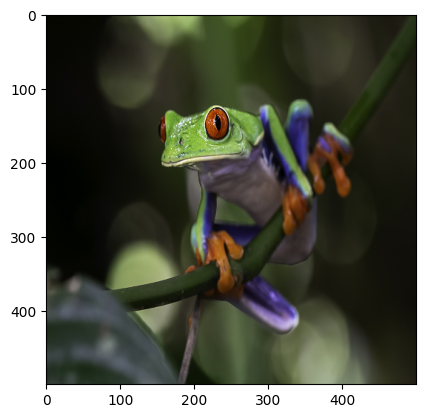

In [29]:
# using the model for inference (prediction)
import matplotlib.pyplot as plt
import cv2
from skimage import io

input_img= "http://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane1.png"

input_img = io.imread(input_img)
#scale up to meet the size requirements.
#If you are enlarging the image, you should prefer to use INTER_LINEAR or INTER_CUBIC interpolation.
#If you are shrinking the image, you should prefer to use INTER_AREA interpolation.Cubic interpolation is computationally more complex, and hence slower than linear interpolation.
#However, the quality of the resulting image will be higher.

input_img = cv2.imread('Frog.jpg')
input_img = cv2.resize(input_img, dsize=(500, 500), interpolation=cv2.INTER_CUBIC)
print('Input Dimensions - Image : ',input_img.shape)
plt.imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))

input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)

In [30]:
class_labels = {
    0: 'airplane',
    1: 'automobile',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck'
}

In [31]:
# prediction part 
import numpy as np
import keras.utils as image

# interpolation and using the image to predict 
input_img = cv2.resize(input_img, dsize=(224, 224), interpolation=cv2.INTER_CUBIC)
x = image.img_to_array(input_img) #Converts a PIL Image instance to a Numpy array.
x = np.expand_dims(x, axis=0)     # converting into 1 dimensional array
x = preprocess_input(x)           #The preprocess_input function is meant to adequate your image to the format the model requires.
preds = model.predict(x)
class_idx = np.argmax(preds[0])

preds[0]

print("Predicted Class: ", class_labels[np.argmax(preds[0])])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Class:  frog


In [19]:
class_idx

0

In [ ]:
# 0 : airplane, 1: automobile, 2: bird, 3: cat, 4: deer, 5: dog, 6: frog, 7: horse, 8: ship, 9: truck